In [27]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
recordingsDF = '/vol/tensusers2/wharmsen/edLing-RDR/metadata/recordingsDF_child.tsv'
mdfsFile = '/vol/tensusers2/wharmsen/edLing-RDR/subjectiveFluency/child/mdfsOneScoreDF.tsv'

In [29]:
mdfsDF = pd.read_csv(mdfsFile, sep='\t', index_col=0)

# Select only sum scores
df = mdfsDF[mdfsDF['variable'] == 'sumScore'].set_index('file')

df

,variable,median,mean,std
file,,,,
fn000497,sumScore,2.75,2.7500,0.2500
fn000123,sumScore,3.50,3.5000,0.2500
fn000110,sumScore,4.00,3.9167,0.1443
fn000139,sumScore,3.75,3.7500,0.2500
fn000068,sumScore,3.75,3.6667,0.1443
...,...,...,...,...
fn000108,sumScore,3.50,3.3333,0.2887
fn000115,sumScore,4.00,4.0000,0.0000
fn000117,sumScore,3.25,3.1667,0.1443


In [30]:
# Read recordingsDF
recordingDF = pd.read_csv(recordingsDF, sep='\t').rename(columns = {'recordingID' : 'bestand'}).set_index('bestand')

recordingDF['task'] = recordingDF['audioID'].apply(lambda x: x.split('_')[-1])
recordingDF['level'] = recordingDF['audioID'].apply(lambda x: int(x.split('_')[0].split('-')[-1].replace('AVI', '')))

# combiDF
combiDF = pd.concat([df, recordingDF[recordingDF['task'] == 'story1'][['audioID', 'age', 'gender', 'dialect', 'level']]], axis=1)

# Rond af op halven
combiDF['finalScore_round'] = combiDF['mean'].round(0)

combiDF = combiDF.reset_index().set_index('audioID')
combiDF.to_csv(mdfsFile.replace('mdfsOneScoreDF.tsv', 'mdfsOneScoreDF_metadata.tsv'))
combiDF

,index,variable,median,mean,std,age,gender,dialect,level,finalScore_round
audioID,,,,,,,,,,
N000195-AVI9_story1,fn000497,sumScore,2.75,2.7500,0.2500,9.0,M,N3b,9,3.0
N000058-AVI4_story1,fn000123,sumScore,3.50,3.5000,0.2500,9.0,F,N4a,4,4.0
N000051-AVI8_story1,fn000110,sumScore,4.00,3.9167,0.1443,11.0,F,N2c,8,4.0
N000073-AVI5_story1,fn000139,sumScore,3.75,3.7500,0.2500,12.0,M,N4a,5,4.0
N000032-AVI6_story1,fn000068,sumScore,3.75,3.6667,0.1443,8.0,F,N2c,6,4.0
...,...,...,...,...,...,...,...,...,...,...
N000054-AVI9_story1,fn000108,sumScore,3.50,3.3333,0.2887,11.0,F,N2c,9,3.0
N000053-AVI8_story1,fn000115,sumScore,4.00,4.0000,0.0000,11.0,F,N2c,8,4.0
N000055-AVI3_story1,fn000117,sumScore,3.25,3.1667,0.1443,9.0,M,N4a,3,3.0


In [34]:
combiDF['finalScore_round'].value_counts()

finalScore_round
4.0    35
3.0    31
2.0     5
Name: count, dtype: int64

Visualize: Age vs AVI-level

In [35]:
combiDF.loc[:, 'textType'] = [int(x.split('-')[1].split('_')[0].replace('AVI', '')) for x in combiDF.index]
df = combiDF.fillna(14)

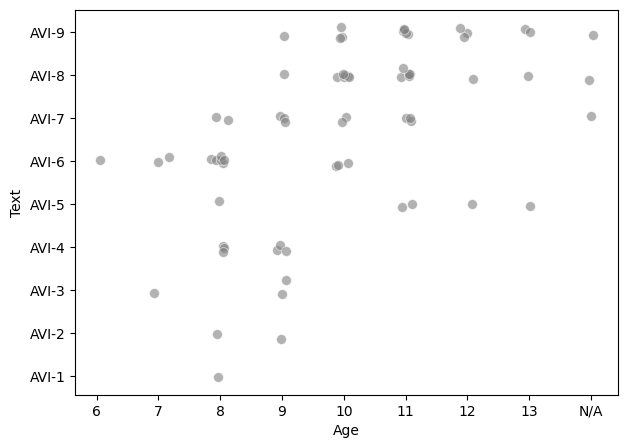

In [36]:
# Example continuous data
rng = np.random.default_rng(42)
df = pd.DataFrame({
    "x": combiDF['age'],
    "y": combiDF['textType']
}).fillna(14)

# Amount of jitter (adjust as needed)
x_jitter_strength = 0.08
y_jitter_strength = 0.08

# Add jitter
df["x_jitter"] = df["x"] + rng.normal(0, x_jitter_strength, len(combiDF['age']))
df["y_jitter"] = df["y"] + rng.normal(0, y_jitter_strength, len(combiDF['textType']))

# Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="x_jitter", y="y_jitter", alpha=0.6, color='grey', s=50)

plt.xticks(np.arange(6,15,1), [str(x) for x in np.arange(6,14,1)] + ['N/A'])
plt.yticks(np.arange(1,10,1), ['AVI-' + str(x) for x in np.arange(1,10,1)])

plt.xlabel("Age")
plt.ylabel("Text")

plt.show()


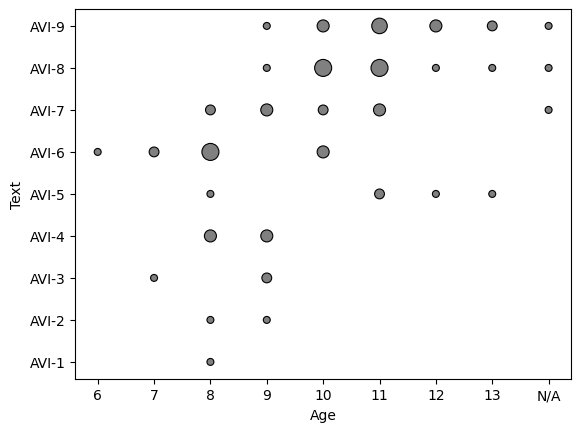

In [37]:
combiDF.loc[:, 'textType'] = [int(x.split('-')[1].split('_')[0].replace('AVI', '')) for x in combiDF.index]

df = combiDF.fillna(14).value_counts(['age', 'textType']).reset_index().sort_values('age')
plt.scatter(df['age'], df['textType'], sizes = [x*25 for x in df['count']], facecolors='grey', edgecolors='black', linewidths=0.8)

plt.xticks(np.arange(6,15,1), [str(x) for x in np.arange(6,14,1)] + ['N/A'])
plt.yticks(np.arange(1,10,1), ['AVI-' + str(x) for x in np.arange(1,10,1)])

plt.xlabel("Age")
plt.ylabel("Text")

plt.show()

Visualize: subjective fluency vs age

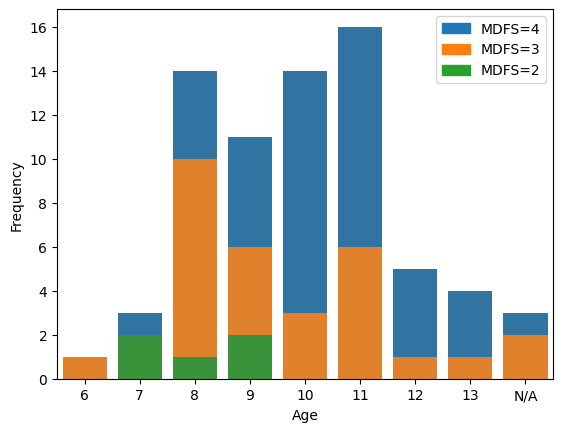

In [38]:
df = combiDF.fillna(99).value_counts(['age', 'finalScore_round']).reset_index()
sns.barplot(combiDF.fillna(99).value_counts(['age']).reset_index(), x='age',y='count', color=sns.color_palette()[0])
sns.barplot(df[df['finalScore_round'] == 3.0], x='age',y='count', color=sns.color_palette()[1])
sns.barplot(df[df['finalScore_round'] == 2.0], x='age',y='count', color=sns.color_palette()[2])

top_bar = mpatches.Patch(color=sns.color_palette()[0], label='MDFS=4')
middle_bar = mpatches.Patch(color=sns.color_palette()[1], label='MDFS=3')
bottom_bar = mpatches.Patch(color=sns.color_palette()[2], label='MDFS=2')
plt.legend(handles=[top_bar, middle_bar, bottom_bar])

plt.xticks(np.arange(0,9,1), [str(x) for x in np.arange(6,14,1)] + ['N/A'])
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()